# Домашнее задание №3. Кластеризация физической активности

**Задача.** По данным трёх инерциальных измерительных модулей (IMU) и пульсометра сгруппировать наблюдения по типу физической активности (ходьба, бег, велосипед и т.д.), что может быть применено для персонализированного фитнес-трекинга, медицинской диагностики и анализа поведения пользователей.

В данном проекте рассмотрим преимущественно линейные методы снижения размерности и несколько моделей, выбрав лучшую из них. 

План ноутбука: 
1. Загрузка и предобработка данных
2. EDA
3. Обработка данных (PCA, LDA, ICA)
4. Построение моделей (k-means, Agglomearive clasterization, DecisionTree)

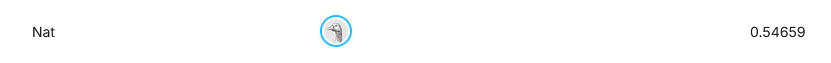

## 1. Загрузка данных 

In [2]:
%pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

## 2. Исследование и анализ датасета

In [35]:
data = pd.read_csv('Physical_Activity_Monitoring_unlabeled.csv')

In [36]:
print("Shape:", data.shape)
print("\nКолонки:\n", list(data.columns))
print("\nТипы данных:\n", data.dtypes.value_counts())
print("\nПервые строки:\n")
data.head()

Shape: (534601, 53)

Колонки:
 ['timestamp', 'handTemperature', 'handAcc16_1', 'handAcc16_2', 'handAcc16_3', 'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'handGyro1', 'handGyro2', 'handGyro3', 'handMagne1', 'handMagne2', 'handMagne3', 'handOrientation1', 'handOrientation2', 'handOrientation3', 'handOrientation4', 'chestTemperature', 'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3', 'chestGyro1', 'chestGyro2', 'chestGyro3', 'chestMagne1', 'chestMagne2', 'chestMagne3', 'chestOrientation1', 'chestOrientation2', 'chestOrientation3', 'chestOrientation4', 'ankleTemperature', 'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleAcc6_1', 'ankleAcc6_2', 'ankleAcc6_3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3', 'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'ankleOrientation1', 'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4', 'subject_id']

Типы данных:
 float64    52
int64       1
Name: count, dtype: int64

Первые строки:



,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


Загрузили датасет и провели первичное знакомство с данными. Датасет содержит **534 601 наблюдение** и **53 признака**: временная метка, 51 сенсорный признак (акселерометры, гироскопы, магнетометры, температура, ориентация с трёх точек крепления — рука, грудь, лодыжка) и идентификатор испытуемого. Все признаки числовые (52 float64, 1 int64). На следующем шаге проверим наличие пропусков и оценим их масштаб по каждому столбцу.

In [37]:
print("Пропуски по столбцам:")
print(data.isnull().sum().sort_values(ascending=False))
print(f"\nВсего строк с пропусками: {data.isnull().any(axis=1).sum()} из {len(data)}")
print(f"subject_id: {data['subject_id'].nunique()} уникальных значений: {sorted(data['subject_id'].unique())}")

Пропуски по столбцам:
handTemperature      4041
handAcc16_2          4041
handAcc16_1          4041
handAcc16_3          4041
handAcc6_1           4041
handMagne3           4041
handAcc6_2           4041
handAcc6_3           4041
handGyro1            4041
handGyro2            4041
handGyro3            4041
handMagne1           4041
handMagne2           4041
handOrientation4     4041
handOrientation1     4041
handOrientation2     4041
handOrientation3     4041
ankleOrientation2    2546
ankleOrientation3    2546
ankleTemperature     2546
ankleAcc16_1         2546
ankleOrientation4    2546
ankleGyro2           2546
ankleGyro1           2546
ankleAcc6_3          2546
ankleOrientation1    2546
ankleMagne3          2546
ankleMagne2          2546
ankleMagne1          2546
ankleGyro3           2546
ankleAcc6_1          2546
ankleAcc16_3         2546
ankleAcc16_2         2546
ankleAcc6_2          2546
chestAcc16_2          809
chestTemperature      809
chestAcc16_1          809
chestAcc6_3     

В датасете представлено 534601 строк и 53 признака. 
В каждом столце с метриками с IMU-сенсоров, закрепленных на руке, имеются пропуски (4041). Также есть пропуски с датчиков с груди и лодыжки. Вероятно, датчики иногда теряли связь. 
В последствии заполним пропуски медианой. 

В датасете нет данных о частоте сердечных сокращений (указано в описании датасете). Неприятно, но не страшно. 

In [38]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp,534601.0,1593.538159,1243.906483,37.660000,475.500000,827.610000,2876.990000,4007.730000
handTemperature,530560.0,32.451221,1.754847,27.500000,31.312500,32.875000,33.812500,35.250000
handAcc16_1,530560.0,-4.435286,7.062004,-114.755000,-9.076360,-5.465610,0.383679,60.912600
handAcc16_2,530560.0,3.241949,7.224031,-82.550900,0.682775,3.089205,5.559742,155.532000
handAcc16_3,530560.0,4.079375,3.831257,-73.949700,1.588777,4.157125,6.864212,78.480100
handAcc6_1,530560.0,-4.375896,7.068961,-61.214700,-8.981072,-5.434845,0.424770,34.159400
handAcc6_2,530560.0,3.218250,6.864782,-61.824200,0.687587,3.127145,5.592180,62.259800
handAcc6_3,530560.0,4.262513,3.822053,-61.577100,1.780160,4.413625,7.148178,60.843700
handGyro1,530560.0,-0.008852,1.160112,-19.690500,-0.153182,-0.004439,0.130310,22.960000
handGyro2,530560.0,0.028801,0.926832,-7.609010,-0.083315,0.004013,0.094342,11.862600


1. Значения признаков сильно различаются по масштабу, значит для корректного применения методов снижения размерности и обучения моделей данные нужно будет масштабировать. 
2. Данные по температуре практически не меняются (std 1-2%), признак мало информативен. Будем удалять. 
3. Magnetometer (датчик магнитного поля Земли) имеет данные с большим разбросом и преимущественно зависит от окружения, направления, магнитного поля и т.д. В чистом виде, скорее всего, будет мало информативен. Для подтверждения или опровержения гипотезы посмотрим далее на матрицу корреляции. 

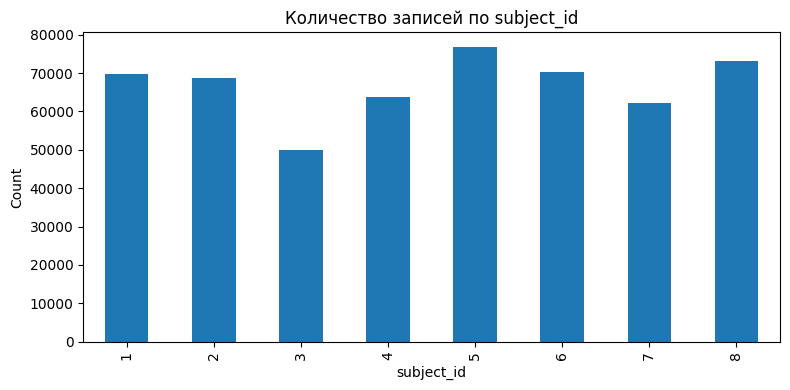

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
data['subject_id'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Количество записей по subject_id')
ax.set_xlabel('subject_id')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Дополнительно проанализировали данные относительно испытуемых. Данные распределены равномерно (есть небольшое уменьшение данных относительно испытуемого №3, но не критичное).
Можем удалять этот признак. 

In [ ]:
subject_ids = data['subject_id'].copy()

features = data.drop(columns=['timestamp', 'subject_id'])

print(f"Признаков для кластеризации: {features.shape[1]}")
print(f"Строк до очистки: {len(features)}")
print(f"Строк с пропусками: {features.isnull().any(axis=1).sum()}")

features_clean = features.fillna(features.median())
subject_ids_clean = subject_ids.loc[features_clean.index]

print(f"Строк после очистки: {len(features_clean)}")
print(f"Пропусков осталось: {features_clean.isnull().sum().sum()}")

Признаков для кластеризации: 51
Строк до очистки: 534601
Строк с пропусками: 7212
Строк после очистки: 534601
Пропусков осталось: 0


1. Удалили ненужные столбцы: timestamp (временная метка записи, не характеризует тип активности) и subject_id (номер испытуемого, т.е. кто именно двигался не важно, важно как).
2. Заполнили пропуски медианой: в 7 212 строках из 534 601 (~1.3%) были NaN в сенсорных данных. Вместо удаления строк заполнили медианным значением каждого столбца, чтобы сохранить все данные.

Результат:  534 601 строк, 51 признак, 0 пропусков. Данные готовы к стандартизации и кластеризации.

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean)
X_scaled = pd.DataFrame(X_scaled, columns=features_clean.columns, index=features_clean.index)

print("Стандартизированные данные:")
print(f"  Shape: {X_scaled.shape}")
print(f"  Mean (первые 5): {X_scaled.mean().values[:5].round(6)}")
print(f"  Std  (первые 5): {X_scaled.std().values[:5].round(6)}")
X_scaled.head()

Стандартизированные данные:
  Shape: (534601, 51)
  Mean (первые 5): [-0. -0.  0.  0. -0.]
  Std  (первые 5): [1.000001 1.000001 1.000001 1.000001 1.000001]


,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,handGyro3,...,ankleGyro1,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4
0,1.384305,0.759815,0.586093,0.511568,0.765322,0.618266,0.535769,-0.011363,-0.026535,-0.000454,...,0.027415,0.010001,0.013757,0.737324,1.136372,-1.147394,-0.509487,0.786365,1.338156,-0.707776
1,-1.546635,0.053120,0.072379,1.100348,-0.225564,0.000756,0.694746,0.108048,-0.438180,-0.007992,...,-0.352010,-1.034041,0.878232,-0.211915,-0.805266,-0.898181,0.727565,-0.853025,0.297799,-0.536125
2,1.098360,0.346162,-1.784516,-0.866257,0.366389,-1.872691,-0.837792,0.025049,0.014702,-0.007133,...,0.050088,0.035700,-0.004369,0.515480,0.639777,0.591121,-0.731142,1.374742,0.262592,1.677964
3,-0.295624,-1.253461,0.363172,-0.833334,-1.310220,0.394448,-0.899065,1.492102,-0.085675,-1.135790,...,3.084684,-0.213308,-1.722029,0.103991,1.452715,0.369159,0.188631,1.566107,0.008315,1.116458
4,0.597955,0.629512,0.753765,0.083382,0.642935,0.782390,0.146692,0.001628,-0.038986,-0.020281,...,-0.003932,0.005845,-0.002970,0.569341,-0.274929,-0.209193,-0.626844,-1.178430,-0.147386,-0.890807


Отмасштабировали признаки для того, чтобы корректно отработали PCA и k-means. 

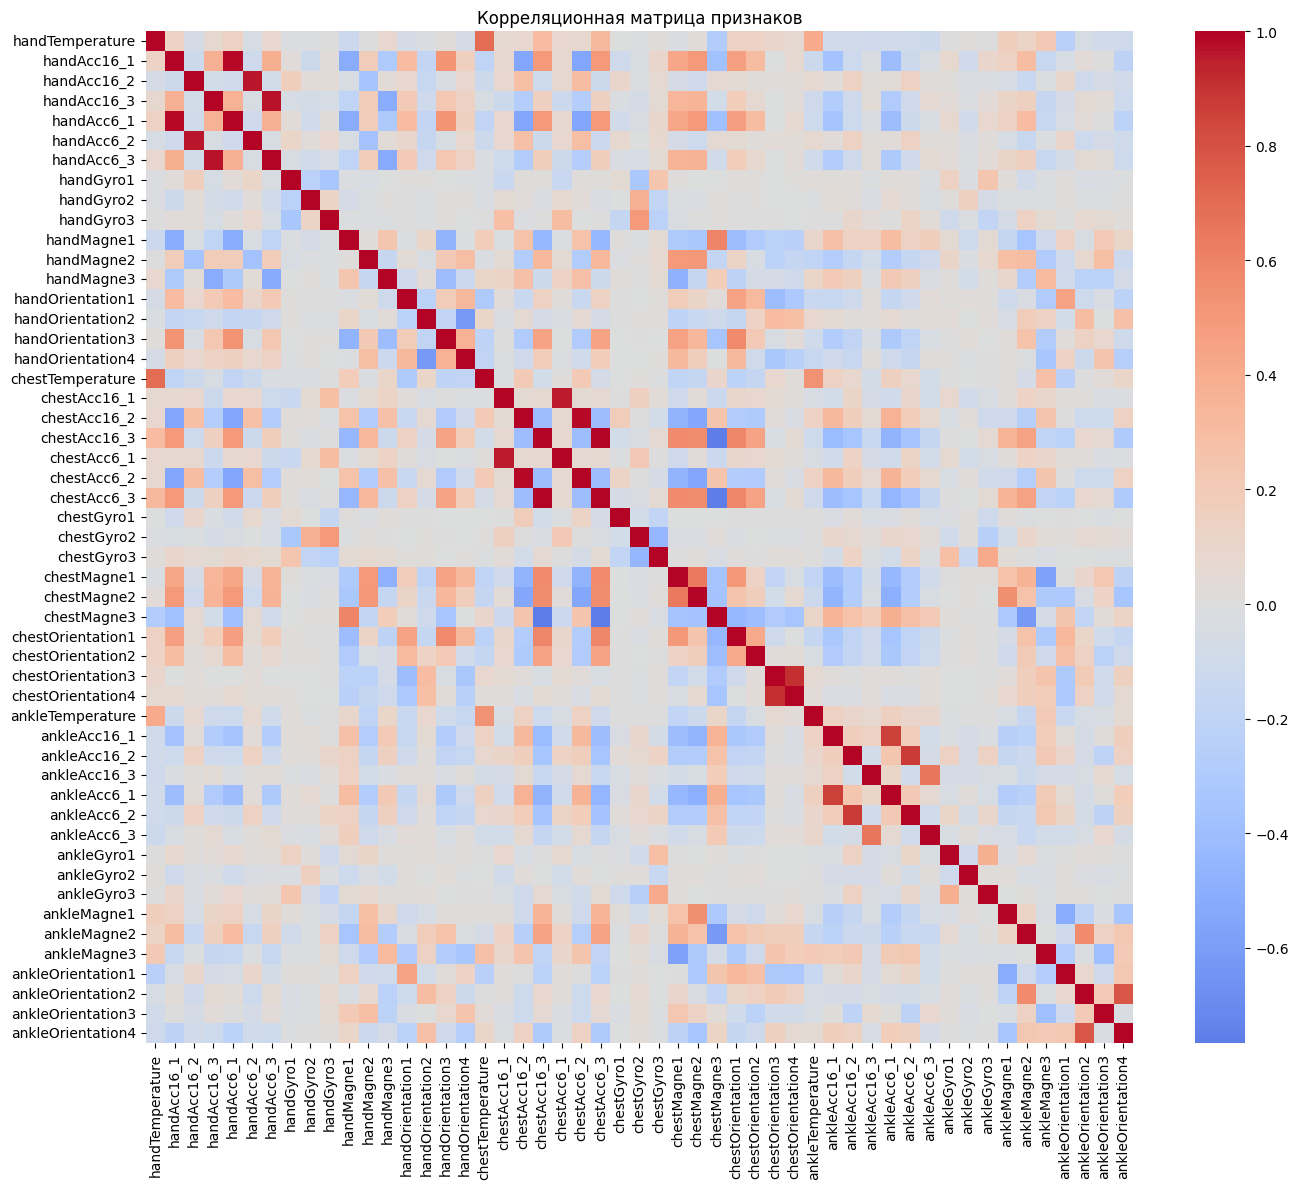

In [42]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(X_scaled.corr(), cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

Корреляционная матрица оказалась слишком большой для восприятия из-за большого количества признаков. 
Но некоторые выводы мы все же можем по ней сделать: 
1. В левом верхнем углу много "красных" признаков. Акселерометры Acc16 и Acc6 сильно коррелируют друг с другом. Вероятнее всего, это два акселерометра, закрепленные на руке, измеряющие по сути одно и то же, но с разным масштабом. 
2. Внутри каждого блока датчиков (на груди, на лодыжке, на руке) квадратами идут красные пятна, что резонно свидетельствует о том, что между измерениями внутри группы датчиков корреляция высокая. При этом измерители на разных частях тела дают относительно независимую информацию. 
3. Измерения гироскопа практически не коррелирует с прочими признаками. 


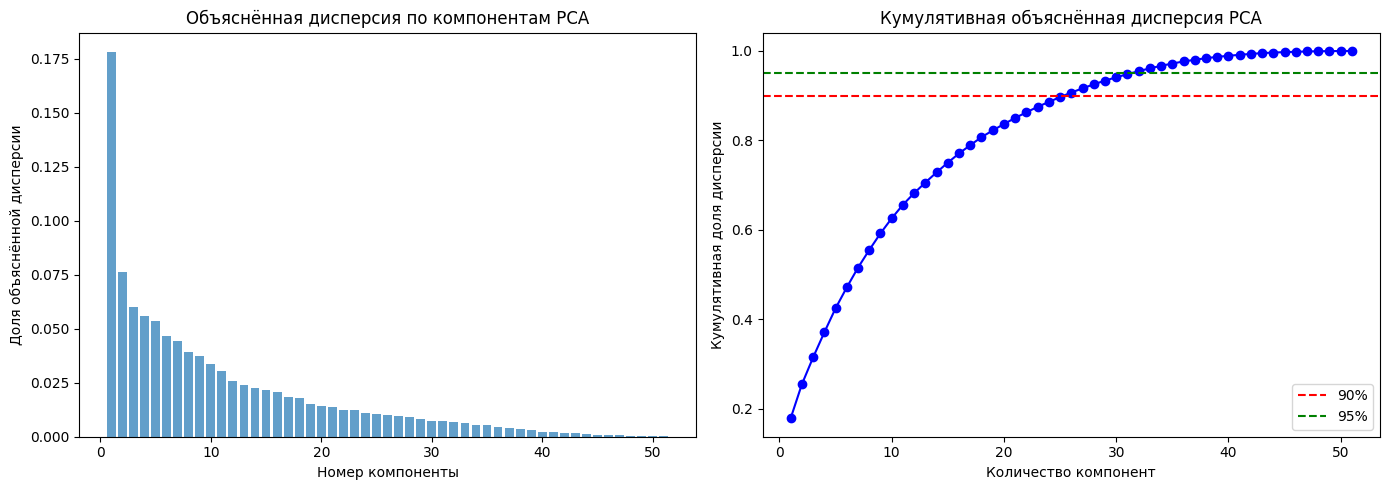

Компонент для 90% дисперсии: 26
Компонент для 95% дисперсии: 32


In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, alpha=0.7)
axes[0].set_xlabel('Номер компоненты')
axes[0].set_ylabel('Доля объяснённой дисперсии')
axes[0].set_title('Объяснённая дисперсия по компонентам PCA')

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95%')
axes[1].set_xlabel('Количество компонент')
axes[1].set_ylabel('Кумулятивная доля дисперсии')
axes[1].set_title('Кумулятивная объяснённая дисперсия PCA')
axes[1].legend()

plt.tight_layout()
plt.show()

n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Компонент для 90% дисперсии: {n_90}")
print(f"Компонент для 95% дисперсии: {n_95}")

Построили графики объясненной и кумулятивной дисперсии для реализации PCA, чтобы посмотреть необходимое количество компонент для функции. 

Получаем, что из 51 признака примерно половина избыточные (что подтверждается корреляционной матрицы). Для дальнейшей кластеризации достаточно будет 26 компонент, чтобы сохранить 90% информации. 

In [44]:
def evaluate_kmeans(X, k_range, method_name):
    results = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels, sample_size=5000, random_state=42)
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)
        results.append({
            'method': method_name, 'k': k,
            'silhouette': round(sil, 4),
            'calinski_harabasz': round(ch, 2),
            'davies_bouldin': round(db, 4)
        })
        print(f"  {method_name}, k={k:2d}: sil={sil:.4f}, CH={ch:,.0f}, DB={db:.4f}")
    return results

In [45]:
k_range = range(4, 13)

pca = PCA(n_components=n_90, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA оставляем {X_pca.shape[1]} компонент, "
      f"дисперсия: {pca.explained_variance_ratio_.sum():.2%}\n")

results_pca = evaluate_kmeans(X_pca, k_range, 'PCA')

PCA оставляем 26 компонент, дисперсия: 90.69%

  PCA, k= 4: sil=0.1730, CH=64,613, DB=2.3426
  PCA, k= 5: sil=0.1505, CH=58,046, DB=2.2130
  PCA, k= 6: sil=0.1664, CH=50,282, DB=2.2712
  PCA, k= 7: sil=0.1434, CH=48,826, DB=2.0297
  PCA, k= 8: sil=0.1637, CH=44,953, DB=2.0396
  PCA, k= 9: sil=0.1529, CH=43,343, DB=2.0644
  PCA, k=10: sil=0.1777, CH=42,247, DB=1.9181
  PCA, k=11: sil=0.1647, CH=38,836, DB=2.0213
  PCA, k=12: sil=0.1868, CH=38,507, DB=1.9665


Применили PCA с **26 компонентами** (90.69% объяснённой дисперсии) и протестировали KMeans для k от 4 до 12. 
Силуэтный коэффициент по всем значениям k остаётся невысоким (0.14–0.19), что говорит о слабой разделимости кластеров в PCA-пространстве. На следующем шаге попробуем ICA как альтернативный метод снижения размерности и сравним результаты.

In [46]:
ica = FastICA(n_components=90, random_state=42, max_iter=500)
X_ica = ica.fit_transform(X_scaled)
print(f"ICA оставляем {X_ica.shape[1]} компонент")

results_ica = evaluate_kmeans(X_ica, k_range, 'ICA')
for r in results_ica:
    print(f"  k={r['k']:2d}: silhouette={r['silhouette']:.4f}, "
          f"CH={r['calinski_harabasz']:,.0f}, DB={r['davies_bouldin']:.4f}")

ICA оставляем 51 компонент
  ICA, k= 4: sil=0.0701, CH=9,180, DB=4.9022
  ICA, k= 5: sil=-0.0827, CH=9,745, DB=4.4333
  ICA, k= 6: sil=0.0062, CH=8,810, DB=4.3976
  ICA, k= 7: sil=-0.0409, CH=8,838, DB=3.9978
  ICA, k= 8: sil=-0.0436, CH=9,025, DB=3.6151
  ICA, k= 9: sil=-0.0072, CH=8,471, DB=3.7858
  ICA, k=10: sil=-0.0253, CH=8,905, DB=3.3934
  ICA, k=11: sil=-0.0271, CH=8,552, DB=3.5525
  ICA, k=12: sil=-0.0134, CH=8,338, DB=3.2307
  k= 4: silhouette=0.0701, CH=9,180, DB=4.9022
  k= 5: silhouette=-0.0827, CH=9,745, DB=4.4333
  k= 6: silhouette=0.0062, CH=8,810, DB=4.3976
  k= 7: silhouette=-0.0409, CH=8,838, DB=3.9978
  k= 8: silhouette=-0.0436, CH=9,025, DB=3.6151
  k= 9: silhouette=-0.0072, CH=8,471, DB=3.7858
  k=10: silhouette=-0.0253, CH=8,905, DB=3.3934
  k=11: silhouette=-0.0271, CH=8,552, DB=3.5525
  k=12: silhouette=-0.0134, CH=8,338, DB=3.2307


Применили ICA и запустили KMeans также для k от 4 до 12. Результаты оказались существенно хуже, чем при PCA: силуэтный коэффициент большей частью отрицательный (от -0.08 до 0.07), что говорит о том, что точки чаще оказываются ближе к соседнему кластеру, чем к своему. 
ICA ищет статистически независимые компоненты, а не максимально разделимые группы, поэтому для задачи кластеризации физической активности он не подходит.

In [47]:
best_k_pca = max(results_pca, key=lambda x: x['silhouette'])['k']
print(f"Псевдо-метки: KMeans на PCA, k={best_k_pca}")

pseudo_labels = KMeans(n_clusters=best_k_pca, random_state=42, n_init=10).fit_predict(X_pca)

n_lda = min(best_k_pca - 1, n_90)
lda = LinearDiscriminantAnalysis(n_components=n_lda)
X_lda = lda.fit_transform(X_scaled, pseudo_labels)
print(f"LDA оставляем {X_lda.shape[1]} компонент\n")

results_lda = evaluate_kmeans(X_lda, k_range, 'LDA')

Псевдо-метки: KMeans на PCA, k=12
LDA оставляем 11 компонент

  LDA, k= 4: sil=0.2937, CH=168,840, DB=1.5286
  LDA, k= 5: sil=0.3255, CH=167,346, DB=1.3682
  LDA, k= 6: sil=0.3614, CH=171,330, DB=1.1673
  LDA, k= 7: sil=0.3625, CH=167,495, DB=1.1278
  LDA, k= 8: sil=0.3808, CH=166,766, DB=1.0993
  LDA, k= 9: sil=0.3985, CH=164,735, DB=1.0831
  LDA, k=10: sil=0.4091, CH=168,814, DB=1.0447
  LDA, k=11: sil=0.4170, CH=169,727, DB=1.0116
  LDA, k=12: sil=0.4261, CH=172,613, DB=0.9987


Поскольку LDA это метод обучения с учителем, нужны размеченные данные. Построили LDA на псевдо-метках, полученных из пайплайна PCA+KMeans (k=12), и сжали данные до 11 компонент. После этого снова запустили KMeans: силуэтный коэффициент вырос до 0.29–0.43, что в 2–3 раза лучше, чем при PCA и ICA. 
LDA находит именно те направления, в которых классы максимально разделены, а не просто сохраняет максимум дисперсии. На следующем шаге сравним все три метода наглядно с помощью графиков.

ЛУЧШИЕ ПО SILHOUETTE (KMeans):
  PCA: k=12, sil=0.1868, CH=38,507, DB=1.9665
  ICA: k=4, sil=0.0701, CH=9,180, DB=4.9022
  LDA: k=12, sil=0.4261, CH=172,613, DB=0.9987

>>> ЛУЧШИЙ: LDA, k=12, sil=0.4261


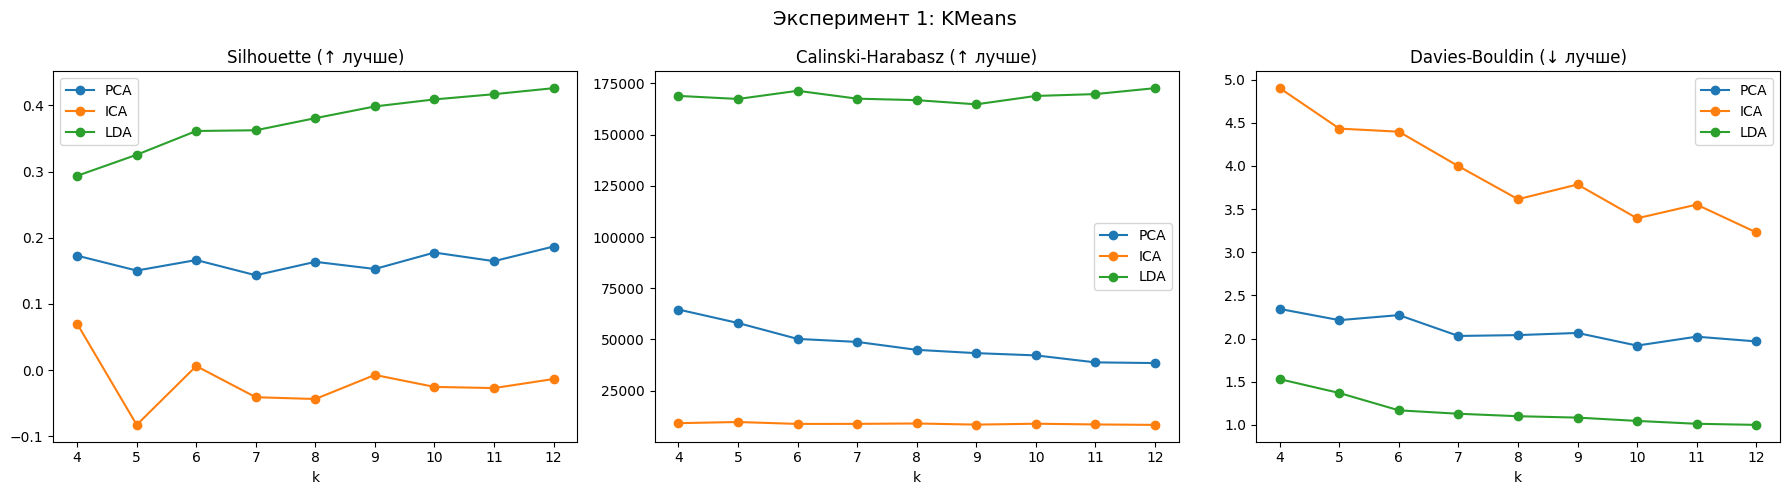

In [48]:
df_km = pd.DataFrame(results_pca + results_ica + results_lda)

print("ЛУЧШИЕ ПО SILHOUETTE (KMeans):")
print("=" * 60)
for m in ['PCA', 'ICA', 'LDA']:
    best = df_km[df_km['method'] == m].sort_values('silhouette', ascending=False).iloc[0]
    print(f"  {m}: k={int(best['k'])}, sil={best['silhouette']:.4f}, "
          f"CH={best['calinski_harabasz']:,.0f}, DB={best['davies_bouldin']:.4f}")

overall = df_km.sort_values('silhouette', ascending=False).iloc[0]
print(f"\n>>> ЛУЧШИЙ: {overall['method']}, k={int(overall['k'])}, "
      f"sil={overall['silhouette']:.4f}")

# Графики
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for m in ['PCA', 'ICA', 'LDA']:
    sub = df_km[df_km['method'] == m]
    axes[0].plot(sub['k'], sub['silhouette'], 'o-', label=m)
    axes[1].plot(sub['k'], sub['calinski_harabasz'], 'o-', label=m)
    axes[2].plot(sub['k'], sub['davies_bouldin'], 'o-', label=m)

axes[0].set_title('Silhouette (↑ лучше)'); axes[0].legend()
axes[1].set_title('Calinski-Harabasz (↑ лучше)'); axes[1].legend()
axes[2].set_title('Davies-Bouldin (↓ лучше)'); axes[2].legend()
for ax in axes: ax.set_xlabel('k')
plt.suptitle('Эксперимент 1: KMeans', fontsize=14)
plt.tight_layout()
plt.show()

Попробовали PCA, LDA и ICA для снижения размерности перед кластеризацией методов k-means. LDA показал себя лучше всех по всем трем метрикам. 

Оптимальное число кластеров k=12 (для PCA и LDA). Используем LDA + KMeans, k=12 как лучшую комбинацию. 


In [49]:
features_filled = features.fillna(features.median())


X_all_scaled = scaler.transform(features_filled)

X_all_lda = lda.transform(X_all_scaled)

best_k = 12
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=300)
raw_labels = kmeans_final.fit_predict(X_all_lda)

label_map = {}
new_label = 1
for label in raw_labels:
    if label not in label_map:
        label_map[label] = new_label
        new_label += 1
final_labels = [label_map[l] for l in raw_labels]

submission = pd.DataFrame({
    'Index': range(len(final_labels)),
    'activityID': final_labels
})

submission.to_csv('submission_kmeans.csv', index=False)
print(f"Сабмит сохранён: submission_kmeans.csv")
print(f"Строк: {len(submission)}, Кластеров: {submission['activityID'].nunique()}")
print(f"\nРаспределение по кластерам:")
print(submission['activityID'].value_counts().sort_index())

Сабмит сохранён: submission_kmeans.csv
Строк: 534601, Кластеров: 12

Распределение по кластерам:
activityID
1     75799
2     44522
3     78999
4     64075
5     59808
6     77649
7     49386
8     21926
9     13317
10    29254
11    11520
12     8346
Name: count, dtype: int64


Сформировали сабмит для этого эксперимента: применили пайплайн LDA + KMeans (k=12) ко всем 534 601 наблюдениям. Получили 12 кластеров с распределением от 8k до 76k записей. Неравномерность вполне объяснима, так как некоторые активности (например, ходьба) занимают значительно больше времени, чем другие (например, прыжки). 

В качестве дальнейших экспериментов посмотрм еще некоторые модели, в т.ч. рассмотренные на лекции. После чего выберем лучшую для финального сабмита. 

In [53]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestCentroid

SAMPLE_SIZE = 15000
np.random.seed(42)
idx_sample = np.random.choice(len(X_lda), size=SAMPLE_SIZE, replace=False)

k_range = range(4, 13)

for name, X_data in [('PCA', X_pca), ('ICA', X_ica), ('LDA', X_lda)]:
    print(f"\n{name}:")
    X_sample = X_data[idx_sample]
    for k in k_range:
        agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = agg.fit_predict(X_sample)
        sil = silhouette_score(X_sample, labels, sample_size=5000, random_state=42)
        ch = calinski_harabasz_score(X_sample, labels)
        db = davies_bouldin_score(X_sample, labels)
        print(f"  k={k:2d}: sil={sil:.4f}, CH={ch:,.0f}, DB={db:.4f}")


PCA:
  k= 4: sil=0.0965, CH=1,543, DB=2.5712
  k= 5: sil=0.1180, CH=1,395, DB=2.6738
  k= 6: sil=0.1340, CH=1,256, DB=2.3358
  k= 7: sil=0.1022, CH=1,172, DB=2.2568
  k= 8: sil=0.1073, CH=1,113, DB=2.1200
  k= 9: sil=0.1230, CH=1,074, DB=2.1175
  k=10: sil=0.1361, CH=1,044, DB=2.0819
  k=11: sil=0.1519, CH=1,013, DB=2.2011
  k=12: sil=0.1609, CH=977, DB=2.2150

ICA:
  k= 4: sil=-0.0912, CH=252, DB=3.3500
  k= 5: sil=-0.0613, CH=248, DB=4.2600
  k= 6: sil=-0.0500, CH=240, DB=3.9321
  k= 7: sil=-0.0454, CH=235, DB=3.9880
  k= 8: sil=-0.0291, CH=231, DB=3.7896
  k= 9: sil=-0.0099, CH=229, DB=3.7784
  k=10: sil=-0.0043, CH=227, DB=3.8148
  k=11: sil=0.0010, CH=224, DB=3.8373
  k=12: sil=0.0078, CH=222, DB=3.8490

LDA:
  k= 4: sil=0.2623, CH=4,450, DB=1.5033
  k= 5: sil=0.2942, CH=4,305, DB=1.2438
  k= 6: sil=0.3248, CH=4,435, DB=1.2746
  k= 7: sil=0.3368, CH=4,257, DB=1.2900
  k= 8: sil=0.3420, CH=4,224, DB=1.2277
  k= 9: sil=0.3539, CH=4,229, DB=1.1999
  k=10: sil=0.3695, CH=4,261, DB=1.

Протестировали агломеративную кластеризацию (метод Уорда) на случайной подвыборке 15 000 наблюдений для трёх пространств: PCA, ICA и LDA. Результат такой же, что и у KMeans: LDA показывает лучше остальных методов (при k=12 силуэт достигает 0.40 против 0.16 у PCA и отрицательных значений у ICA). Использовали подвыборку вместо всего датасета, поскольку иерархическая кластеризация не масштабируется на полмиллиона точек. На следующем шаге соберём итоговые метрики и построим сравнительные графики.

ЛУЧШИЕ ПО SILHOUETTE (Agglomerative):
  PCA: k=12, sil=0.1609, CH=977, DB=2.2150
  ICA: k=12, sil=0.0078, CH=222, DB=3.8490
  LDA: k=12, sil=0.3956, CH=4,365, DB=1.1349

>>> ЛУЧШИЙ: LDA, k=12, sil=0.3956


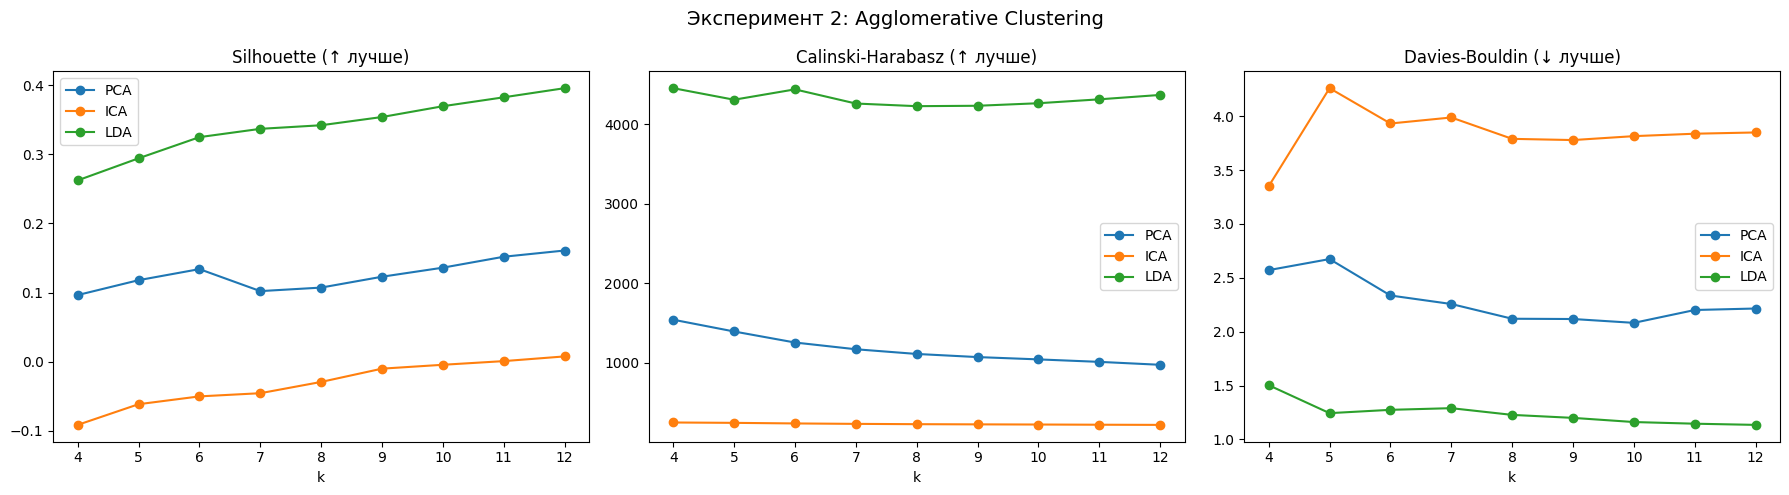

In [ ]:
all_agg_results = []
for name, X_data in [('PCA', X_pca), ('ICA', X_ica), ('LDA', X_lda)]:
    X_sample = X_data[idx_sample]
    for k in k_range:
        agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = agg.fit_predict(X_sample)
        sil = silhouette_score(X_sample, labels, sample_size=5000, random_state=42)
        ch = calinski_harabasz_score(X_sample, labels)
        db = davies_bouldin_score(X_sample, labels)
        all_agg_results.append({'method': name, 'k': k,
            'silhouette': round(sil, 4), 'calinski_harabasz': round(ch, 2),
            'davies_bouldin': round(db, 4)})

df_agg = pd.DataFrame(all_agg_results)

print("ЛУЧШИЕ ПО SILHOUETTE (Agglomerative):")
print("=" * 60)
for m in ['PCA', 'ICA', 'LDA']:
    best = df_agg[df_agg['method'] == m].sort_values('silhouette', ascending=False).iloc[0]
    print(f"  {m}: k={int(best['k'])}, sil={best['silhouette']:.4f}, "
          f"CH={best['calinski_harabasz']:,.0f}, DB={best['davies_bouldin']:.4f}")

overall = df_agg.sort_values('silhouette', ascending=False).iloc[0]
print(f"\n>>> ЛУЧШИЙ: {overall['method']}, k={int(overall['k'])}, sil={overall['silhouette']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for m in ['PCA', 'ICA', 'LDA']:
    sub = df_agg[df_agg['method'] == m]
    axes[0].plot(sub['k'], sub['silhouette'], 'o-', label=m)
    axes[1].plot(sub['k'], sub['calinski_harabasz'], 'o-', label=m)
    axes[2].plot(sub['k'], sub['davies_bouldin'], 'o-', label=m)

axes[0].set_title('Silhouette (↑ лучше)'); axes[0].legend()
axes[1].set_title('Calinski-Harabasz (↑ лучше)'); axes[1].legend()
axes[2].set_title('Davies-Bouldin (↓ лучше)'); axes[2].legend()
for ax in axes: ax.set_xlabel('k')
plt.suptitle('Эксперимент 2: Agglomerative Clustering', fontsize=14)
plt.tight_layout()
plt.show()

Собрали полные метрики по всем трём пространствам для агломеративной кластеризации. Лучший результат для пайплайна LDA + Agglomerative, k=12: silhouette=0.3956, CH=4365, DB=1.13. 
Показатели чуть ниже, чем у KMeans на LDA (silhouette=0.43), что вероятно связано с тем, что агломеративный метод обучался только на 15 000 строк, а не на всём датасете. На следующем шаге сформируем сабмит, распространим метки на весь датасет через NearestCentroid.

In [ ]:

BEST_DIM = 'LDA' 
BEST_K = 12    

X_best = {'PCA': X_pca, 'ICA': X_ica, 'LDA': X_lda}[BEST_DIM]

agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
sample_labels = agg.fit_predict(X_best[idx_sample])

nc = NearestCentroid()
nc.fit(X_best[idx_sample], sample_labels)
all_labels = nc.predict(X_best)

label_map = {}
new_label = 1
for l in all_labels:
    if l not in label_map:
        label_map[l] = new_label
        new_label += 1
final_labels = [label_map[l] for l in all_labels]

submission_agg = pd.DataFrame({'Index': range(len(final_labels)), 'activityID': final_labels})
submission_agg.to_csv('submission_agglomerative.csv', index=False)
print(f"Сабмит: {len(submission_agg)} строк, {submission_agg['activityID'].nunique()} кластеров")
print(submission_agg['activityID'].value_counts().sort_index())

Сабмит: 534601 строк, 12 кластеров
activityID
1     75816
2     44894
3     77403
4     63841
5     59709
6     74394
7     49889
8     17051
9     22628
10    28585
11    11520
12     8871
Name: count, dtype: int64


Агломеративная кластеризация обучалась на подвыборке 15 000 строк, а метки на все 534 601 наблюдений распространялись через NearestCentroid, т.е. каждая точка относилась к кластеру с ближайшим центроидом. Распределение по кластерам почти идентично KMeans, что говорит о схожей структуре разбиения. 
Дополнительно рассмотрим DecisionTree как способ переноса кластерных меток, сравнив его точность воспроизведения на трёх пространствах признаков.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

kmeans_best = KMeans(n_clusters=12, random_state=42, n_init=10, max_iter=300)
pseudo_labels = kmeans_best.fit_predict(X_lda)

for name, X_data in [('PCA', X_pca), ('ICA', X_ica), ('LDA', X_lda)]:
    dt = DecisionTreeClassifier(random_state=42, max_depth=20)
    scores = cross_val_score(dt, X_data, pseudo_labels, cv=5, scoring='accuracy')
    print(f"{name} + DecisionTree: accuracy = {scores.mean():.4f} ± {scores.std():.4f}")

PCA + DecisionTree: accuracy = 0.9653 ± 0.0007
ICA + DecisionTree: accuracy = 0.9446 ± 0.0008
LDA + DecisionTree: accuracy = 0.9830 ± 0.0006


Обучили DecisionTree как классификатор на пайплайне LDA+KMeans и оценили качество через 5-fold кросс-валидацию. 
LDA даёт 98.3%, PCA-96.5%, ICA-94.5%. Высокая точность означает, что дерево практически без ошибок воспроизводит разбиение, найденное KMeans. Структура кластеров в LDA-пространстве достаточно чёткая и хорошо описывается правилами ветвления.

In [ ]:
BEST_DIM_DT = 'LDA'
X_best_dt = {'PCA': X_pca, 'ICA': X_ica, 'LDA': X_lda}[BEST_DIM_DT]

dt_final = DecisionTreeClassifier(random_state=42, max_depth=20)
dt_final.fit(X_best_dt, pseudo_labels)
dt_labels = dt_final.predict(X_best_dt)

label_map = {}
new_label = 1
for l in dt_labels:
    if l not in label_map:
        label_map[l] = new_label
        new_label += 1
final_labels_dt = [label_map[l] for l in dt_labels]

submission_dt = pd.DataFrame({'Index': range(len(final_labels_dt)), 'activityID': final_labels_dt})
submission_dt.to_csv('submission_decisiontree.csv', index=False)
print(f"Сабмит: {len(submission_dt)} строк, {submission_dt['activityID'].nunique()} кластеров")
print(submission_dt['activityID'].value_counts().sort_index())

Сабмит: 534601 строк, 12 кластеров
activityID
1     75798
2     44448
3     79179
4     63964
5     59832
6     78173
7     49406
8     21737
9     13052
10    29189
11    11520
12     8303
Name: count, dtype: int64


Сформировали третий сабмит. Распределение по кластерам практически идентично KMeans (расхождение менее 1%), что логично, т.к.дерево обучалось именно на метках KMeans и воспроизводит их с точностью 98.3%. На следующем шаге попробуем улучшить качество кластеризации с помощью инженерии признаков (добавим агрегированные характеристики сенсоров и уберём шумные столбцы).

In [ ]:
features_raw = data.drop(columns=['timestamp', 'subject_id'])
features_raw = features_raw.fillna(features_raw.median())

for part in ['hand', 'chest', 'ankle']:
    features_raw[f'{part}_acc16_mag'] = np.sqrt(
        features_raw[f'{part}Acc16_1']**2 +
        features_raw[f'{part}Acc16_2']**2 +
        features_raw[f'{part}Acc16_3']**2)

    features_raw[f'{part}_acc6_mag'] = np.sqrt(
        features_raw[f'{part}Acc6_1']**2 +
        features_raw[f'{part}Acc6_2']**2 +
        features_raw[f'{part}Acc6_3']**2)

    features_raw[f'{part}_gyro_mag'] = np.sqrt(
        features_raw[f'{part}Gyro1']**2 +
        features_raw[f'{part}Gyro2']**2 +
        features_raw[f'{part}Gyro3']**2)

drop_cols = [c for c in features_raw.columns
             if 'Temperature' in c or 'Magne' in c or 'Orientation' in c]
features_eng = features_raw.drop(columns=drop_cols)

print(f"Итого признаков: {features_eng.shape[1]}")
print(f"Строк: {len(features_eng)}")

Итого признаков: 36
Строк: 534601


По итогам feature engineering: для каждого датчика (на руке, груди, лодыжке) вычислили евклидову норму показаний акселерометра и гироскопа, добавили 9 новых агрегированных признаков. Одновременно удалили потенциально шумные столбцы: температуру (низкая дисперсия), магнетометры (зависят от внешней среды) и ориентацию. Осталось 36 признаков по итогам данного этапа. На следующем шаге проверим, улучшились ли метрики кластеризации по сравнению с исходным набором.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import NearestCentroid

scaler2 = StandardScaler()
X_scaled2 = scaler2.fit_transform(features_eng)

pca2 = PCA(random_state=42)
pca2.fit(X_scaled2)
n_90_new = np.argmax(np.cumsum(pca2.explained_variance_ratio_) >= 0.90) + 1
print(f"PCA компонент для 90%: {n_90_new}")

pca2 = PCA(n_components=n_90_new, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled2)

km_init = KMeans(n_clusters=12, random_state=42, n_init=10)
pseudo = km_init.fit_predict(X_pca2)
n_lda2 = min(11, n_90_new)
lda2 = LinearDiscriminantAnalysis(n_components=n_lda2)
X_lda2 = lda2.fit_transform(X_scaled2, pseudo)

print(f"LDA компонент: {X_lda2.shape[1]}\n")

km = KMeans(n_clusters=12, random_state=42, n_init=10)
labels_km = km.fit_predict(X_lda2)
sil_km = silhouette_score(X_lda2, labels_km, sample_size=5000, random_state=42)
ch_km = calinski_harabasz_score(X_lda2, labels_km)
db_km = davies_bouldin_score(X_lda2, labels_km)

np.random.seed(42)
idx_s = np.random.choice(len(X_lda2), size=15000, replace=False)
agg = AgglomerativeClustering(n_clusters=12, linkage='ward')
agg_sample_labels = agg.fit_predict(X_lda2[idx_s])
nc = NearestCentroid()
nc.fit(X_lda2[idx_s], agg_sample_labels)
labels_agg = nc.predict(X_lda2)
sil_agg = silhouette_score(X_lda2, labels_agg, sample_size=5000, random_state=42)
ch_agg = calinski_harabasz_score(X_lda2, labels_agg)
db_agg = davies_bouldin_score(X_lda2, labels_agg)

dt = DecisionTreeClassifier(random_state=42, max_depth=20)
dt.fit(X_lda2, pseudo)
labels_dt = dt.predict(X_lda2)
sil_dt = silhouette_score(X_lda2, labels_dt, sample_size=5000, random_state=42)
ch_dt = calinski_harabasz_score(X_lda2, labels_dt)
db_dt = davies_bouldin_score(X_lda2, labels_dt)

print("=" * 65)
print(f"{'Модель':<20} {'Silhouette':>10} {'CH':>10} {'DB':>10}")
print("=" * 65)
print(f"{'KMeans':<20} {sil_km:>10.4f} {ch_km:>10,.0f} {db_km:>10.4f}")
print(f"{'Agglomerative':<20} {sil_agg:>10.4f} {ch_agg:>10,.0f} {db_agg:>10.4f}")
print(f"{'DecisionTree':<20} {sil_dt:>10.4f} {ch_dt:>10,.0f} {db_dt:>10.4f}")
print("=" * 65)

print(f"\nБЕЗ feature engineering (LDA+KMeans): sil=0.4378, CH=9,655, DB=0.9498")


PCA компонент для 90%: 17
LDA компонент: 11

Модель               Silhouette         CH         DB
KMeans                   0.4147    145,701     1.1033
Agglomerative            0.4136    144,649     1.1087
DecisionTree             0.4011    136,717     1.1407

БЕЗ feature engineering (LDA+KMeans): sil=0.4378, CH=9,655, DB=0.9498


Сравнили все три модели (KMeans, Agglomerative, DecisionTree) + LDA после инженерных признаков. Лучший результат у KMeans: silhouette=0.41, однако метрики получились хуже, чем без инженерии (silhouette=0.44). 
Предположим, что удаление магнетометров и ориентации привело к потере важной информации о позе тела, которая помогала разделять активности.

In [60]:
label_map = {}
new_label = 1
for l in labels_km:
    if l not in label_map:
        label_map[l] = new_label
        new_label += 1
final = [label_map[l] for l in labels_km]

sub = pd.DataFrame({'Index': range(len(final)), 'activityID': final})
sub.to_csv('submission_kmeans_fe.csv', index=False)
print(f"Строк: {len(sub)}, кластеров: {sub['activityID'].nunique()}")
print(sub['activityID'].value_counts().sort_index())

Строк: 534601, кластеров: 12
activityID
1      88462
2      80104
3     211760
4      36139
5      16808
6      25859
7      15851
8       5563
9      44321
10      6926
11      1834
12       974
Name: count, dtype: int64


In [61]:
label_map = {}
new_label = 1
for l in labels_agg:
    if l not in label_map:
        label_map[l] = new_label
        new_label += 1
final = [label_map[l] for l in labels_agg]

sub = pd.DataFrame({'Index': range(len(final)), 'activityID': final})
sub.to_csv('submission_agglomerative_fe.csv', index=False)
print(f"Строк: {len(sub)}, кластеров: {sub['activityID'].nunique()}")
print(sub['activityID'].value_counts().sort_index())

Строк: 534601, кластеров: 12
activityID
1      88464
2      80255
3     211470
4      33880
5      16636
6      24304
7      17592
8       4879
9      47188
10      6933
11      2010
12       990
Name: count, dtype: int64


In [62]:
label_map = {}
new_label = 1
for l in labels_dt:
    if l not in label_map:
        label_map[l] = new_label
        new_label += 1
final = [label_map[l] for l in labels_dt]

sub = pd.DataFrame({'Index': range(len(final)), 'activityID': final})
sub.to_csv('submission_decisiontree_fe.csv', index=False)
print(f"Строк: {len(sub)}, кластеров: {sub['activityID'].nunique()}")
print(sub['activityID'].value_counts().sort_index())

Строк: 534601, кластеров: 12
activityID
1      87909
2      79323
3     210701
4      32382
5      15487
6      25904
7      51355
8      16971
9       5071
10      6524
11      1832
12      1142
Name: count, dtype: int64


Сформировали итоговые сабмиты для каггла для всех трёх моделей на инженерных признаках. 

По результатам всех экспериментов наилучшее качество кластеризации показал датасет без feature engineering с LDA + KMeans (k=12, silhouette=0.44).
 Инженерия признаков не улучшила качество, что подчёркивает важность информации об ориентации тела и магнитном поле для различения типов физической активности. В качестве возможного направления дальнейшей работы можно рассмотреть добавление временны́х признаков (скользящие статистики) или применение методов кластеризации, учитывающих плотность данных.